In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import imageio
import matplotlib.pyplot as plt
import cv2
import numpy as np
from skimage.exposure import equalize_adapthist


train_dir = '/Users/jordanjones/Downloads/1_HAND_DATASET'

def label_images(train_dir):
    class_map = {
    'Zero - 0': 0,
    'One - 1': 1,
    'Two - 2': 2,
    'Three - 3': 3,
    'Four - 4': 4,
    'Five - 5': 5,
    'Six - 6': 6,
    'Seven - 7': 7,
    'Eight - 8': 8,
    'Nine - 9': 9,
    'C - c': 10 #Would have all classes. This is code for smaller dataset 
}
    images = []
    labels = []

    for folder_name in class_map.keys():
        folder_path = os.path.join(train_dir, folder_name)
        for filename in os.listdir(folder_path):
            if filename == ".DS_Store":
                continue 
            img_path = os.path.join(folder_path,filename)
            class_id = class_map[folder_name]
         
            img = cv2.imread(img_path)                   
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)   
            img = cv2.resize(img, (128,128))             
            img = img.astype('float32') / 255.0          
            
            images.append(img)
            labels.append(class_id)
    return np.array(images), np.array(labels)

x, y = label_images(train_dir)




In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from keras import layers, models
from keras.layers import Softmax




X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(y_train[0].shape)
print(len(y_train))
print(len(X_train))
print(X_train.shape)
print(X_train.dtype)
print(x[0])



()
8798
8798
(8798, 128, 128, 3)
float32
[[[0.627451   0.5882353  0.5411765 ]
  [0.627451   0.5882353  0.5529412 ]
  [0.62352943 0.5921569  0.5568628 ]
  ...
  [0.44313726 0.40392157 0.3764706 ]
  [0.43529412 0.39607844 0.36862746]
  [0.43529412 0.39607844 0.36862746]]

 [[0.61960787 0.5803922  0.53333336]
  [0.61960787 0.5803922  0.5411765 ]
  [0.627451   0.5882353  0.5529412 ]
  ...
  [0.44313726 0.40392157 0.3764706 ]
  [0.43529412 0.39607844 0.36862746]
  [0.43137255 0.39607844 0.36862746]]

 [[0.62352943 0.5764706  0.5254902 ]
  [0.61960787 0.5686275  0.5254902 ]
  [0.61960787 0.5803922  0.5372549 ]
  ...
  [0.4392157  0.4        0.37254903]
  [0.4392157  0.4        0.37254903]
  [0.41960785 0.3882353  0.36078432]]

 ...

 [[0.6431373  0.5921569  0.5137255 ]
  [0.59607846 0.5411765  0.47058824]
  [0.54509807 0.49019608 0.42352942]
  ...
  [0.35686275 0.28235295 0.22745098]
  [0.36862746 0.29411766 0.23137255]
  [0.3372549  0.27450982 0.20392157]]

 [[0.62352943 0.5686275  0.490196

In [ ]:
import wandb
from wandb.keras import WandbCallback

wandb.login()
wandb.init(project="CNN-Hand") 

In [5]:
cnn_model = models.Sequential([layers.Conv2D(filters=16, kernel_size=5, activation='relu', input_shape=(128, 128, 3)),
layers.Conv2D(16, 5, activation='relu'),
layers.MaxPool2D(pool_size=4,
                 padding='valid'),
layers.Conv2D(32, 5, activation='relu'),
layers.Conv2D(64, 3, activation='relu'),

layers.MaxPool2D(pool_size=2, padding='valid'),

layers.Flatten(),
layers.Dense(11, activation='softmax')])
cnn_model.compile(loss= 'sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


In [ ]:
history = cnn_model.fit(X_train, y_train, epochs=12, validation_data=(X_test, y_test), batch_size=32,  callbacks=[WandbCallback()] )


Epoch 1/12
275/275 ━━━━━━━━━━━━━━━━━━━━ 17s 57ms/step - accuracy: 0.8672 - loss: 0.3828 - val_accuracy: 0.8686 - val_loss: 0.3773
Epoch 2/12
275/275 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.9246 - loss: 0.2173 - val_accuracy: 0.9077 - val_loss: 0.3065
Epoch 3/12
275/275 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - accuracy: 0.9545 - loss: 0.1428 - val_accuracy: 0.9436 - val_loss: 0.1913
Epoch 4/12
275/275 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - accuracy: 0.9676 - loss: 0.0961 - val_accuracy: 0.9368 - val_loss: 0.1974
Epoch 5/12
275/275 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.9720 - loss: 0.0812 - val_accuracy: 0.9432 - val_loss: 0.1944
Epoch 6/12
275/275 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.9779 - loss: 0.0644 - val_accuracy: 0.9332 - val_loss: 0.2366
Epoch 7/12
275/275 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.9824 - loss: 0.0564 - val_accuracy: 0.9445 - val_loss: 0.2009
Epoch 8/12
275/275 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.9856 - loss: 0.0477 - va

69/69 - 1s - 15ms/step - accuracy: 0.9445 - loss: 0.2265

Test accuracy: 0.9445454478263855


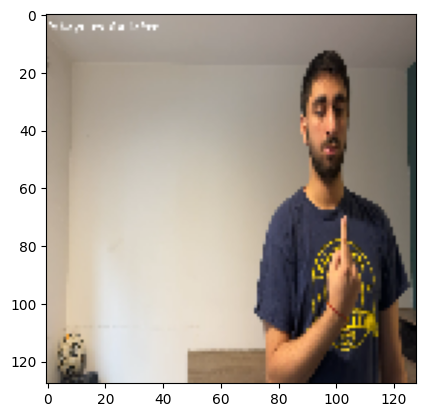

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 929ms/step
1 1


array([[0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [8]:
test_loss, test_acc = cnn_model.evaluate(X_test, y_test, verbose=2)
print('\nTest accuracy:', test_acc)

import numpy as np
import matplotlib.pyplot as plt
import random
num = random.randint(0, 2200)

plt.imshow(X_test[num])
plt.show()


img = np.expand_dims(X_test[num], axis=0) 


pred = cnn_model.predict(img)
pred_class = np.argmax(pred)

print(pred_class, y_test[num])

pred.round(2)

In [9]:
print(X_test.dtype)
X_test.shape

float32


(2200, 128, 128, 3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
5
[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
6
[[0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4
[[0.   0.   0.16 0.   0.6  0.   0.   0.   0.23 0.   0.01]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
5
[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
0
[[0.97 0.   0.   0.   0.01 0.02 0.   0.   0.   0.   0.  ]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
5
[[0.   0.   0.   0.   0.03 0.97 0.   0.   0.   0.   0.  ]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
5
[[0.   0.   0.   0.   0.28 0.64 0.   0.   0.08 0.   0.  ]]


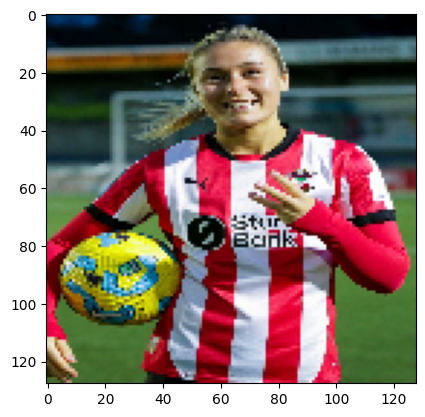

In [10]:
path = '/Users/jordanjones/Downloads/test'
tester = []
for file in os.listdir(path):
    full_path = os.path.join(path, file)
    

    test_im = cv2.imread(full_path)
    if test_im is None:
        continue
    test_im = cv2.cvtColor(test_im, cv2.COLOR_BGR2RGB)   
    test_im = cv2.resize(test_im, (128,128))             
    test_im = test_im.astype('float32') / 255.0 
    
    test_im = np.array(test_im)
    tester.append(test_im)

len(tester)

for im in tester:
    
    im = np.expand_dims(im, axis=0) 
    pred = cnn_model.predict(im)
    pred_class = np.argmax(pred)
    
    print(pred_class)
    print(pred.round(2))
plt.imshow(tester[1])

In [ ]:
cnn_model.save('assignment_model.keras')